<a href="https://colab.research.google.com/github/huiningjiao02-ship-it/Conformer-EEG-BCI-Decoding-Pipeline/blob/main/Conformer_EEG_BCI_Decoding_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conformer-based EEG/BCI Decoding Pipeline for Motor Imagery

## Project Motivation

This notebook upgrades a simple EEG-Conformer reproduction into a modular EEG/BCI decoding pipeline.

Instead of only reporting best-epoch accuracy, this notebook focuses on:

1. Correct task-label mapping for the EEG Motor Movement/Imagery dataset.
2. Leakage-controlled train/validation/test split.
3. Training-only data augmentation.
4. Early stopping and standardized evaluation metrics.
5. Within-subject evaluation.
6. Leave-One-Subject-Out cross-subject evaluation.
7. Model benchmarking against CNN-based baselines.
8. Attention and temporal-occlusion analysis.
9. Pseudo-online BCI command simulation.

## Core Research Insight

Transformer-based EEG decoding is not automatically superior in small-sample EEG settings.  
Its value should be evaluated through strict data protocols, baseline comparison, cross-subject validation, and model interpretability analysis.


In [ ]:
!pip -q install mne einops scikit-learn tqdm

In [ ]:
import os
import copy
import time
import random
import warnings
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

import mne
from mne.datasets import eegbci

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from einops import rearrange

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")


@dataclass
class CFG:
    # Project
    project_name: str = "conformer_eeg_bci_pipeline_30_subjects"
    seed: int = 42

    # Paths
    data_root: str = "/content/eeg_data"
    results_dir: str = "/content/eeg_bci_results"

    # Dataset setting
    run_mode: str = "pure_imagery"
    subjects: Tuple[int, ...] = tuple(range(1, 31))
    runs_cv_original: Tuple[int, ...] = (11, 12, 13, 14)
    runs_pure_imagery: Tuple[int, ...] = (4, 6, 8, 10, 12, 14)

    # EEG preprocessing
    sfreq: int = 250
    l_freq: float = 4.0
    h_freq: float = 38.0
    tmin: float = 0.0
    tmax: float = 4.0

    # Split setting
    test_size: float = 0.20
    val_size: float = 0.15

    # Training
    batch_size: int = 32
    epochs: int = 50
    lr: float = 1e-4
    weight_decay: float = 1e-4
    patience: int = 8
    max_grad_norm: float = 1.0

    # Augmentation
    use_augmentation: bool = True
    aug_segments: int = 8
    aug_multiplier: float = 1.0

    # Model
    n_classes: int = 4
    emb_size: int = 40
    depth: int = 6
    n_heads: int = 4
    dropout: float = 0.6


cfg = CFG()

os.makedirs(cfg.data_root, exist_ok=True)
os.makedirs(cfg.results_dir, exist_ok=True)

if cfg.run_mode == "cv_original":
    RUNS = cfg.runs_cv_original
else:
    RUNS = cfg.runs_pure_imagery

LABEL_NAMES = {
    0: "left_fist",
    1: "right_fist",
    2: "both_fists",
    3: "both_feet"
}

print("Project:", cfg.project_name)
print("Run mode:", cfg.run_mode)
print("Runs:", RUNS)
print("Results directory:", cfg.results_dir)

Project: conformer_eeg_bci_pipeline_30_subjects
Run mode: pure_imagery
Runs: (4, 6, 8, 10, 12, 14)
Results directory: /content/eeg_bci_results


In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Innovation 1: Correct task-label mapping

The original notebook-style reproduction can easily mix up the meaning of T1 and T2 events across different runs.

In the EEG Motor Movement/Imagery dataset, the same annotation names, T1 and T2, have different meanings depending on the run type.

This notebook explicitly defines run-dependent label mapping:

- Left/right fist runs:
  - T1 = left fist
  - T2 = right fist

- Both-fists/both-feet runs:
  - T1 = both fists
  - T2 = both feet

This avoids silently assigning wrong class labels during four-class motor imagery decoding.

In [ ]:
# Cell 5 — Dataset loader with corrected label mapping

from mne.datasets import eegbci


LEFT_RIGHT_RUNS = {3, 4, 7, 8, 11, 12}
FISTS_FEET_RUNS = {5, 6, 9, 10, 13, 14}


def label_from_run_and_annotation(run: int, annotation: str):
    """
    Convert run-dependent T1/T2 annotations into a unified four-class label space.

    Label space:
    0 = left fist
    1 = right fist
    2 = both fists
    3 = both feet

    In EEGMMIDB:
    - For left/right fist runs:
        T1 = left fist
        T2 = right fist

    - For both fists/both feet runs:
        T1 = both fists
        T2 = both feet
    """

    if annotation == "T0":
        return None

    if run in LEFT_RIGHT_RUNS:
        if annotation == "T1":
            return 0
        if annotation == "T2":
            return 1

    if run in FISTS_FEET_RUNS:
        if annotation == "T1":
            return 2
        if annotation == "T2":
            return 3

    return None


def load_eegmmidb_subject(subject: int, runs=RUNS, cfg=cfg):
    """
    Load one subject from the EEG Motor Movement/Imagery dataset.

    Parameters
    ----------
    subject : int
        Subject ID.

    runs : tuple or list
        Run numbers to load.

    cfg : CFG
        Global configuration.

    Returns
    -------
    X : np.ndarray
        EEG trials.
        Shape: [n_trials, n_channels, n_times]

    y : np.ndarray
        Trial labels.
        Shape: [n_trials]

    ch_names : list
        EEG channel names.
    """

    # Download or locate EEGMMIDB files.
    # 用位置参数写法，避免 Colab / linter 对 keyword 写法误报。
    file_paths = eegbci.load_data(
        subject,
        list(runs),
        path=cfg.data_root,
        verbose=False
    )

    all_X = []
    all_y = []
    final_ch_names = None

    for file_path, run in zip(file_paths, runs):
        raw = mne.io.read_raw_edf(
            file_path,
            preload=True,
            verbose=False
        )

        # Standardize channel names.
        eegbci.standardize(raw)

        # Keep EEG channels only.
        raw.pick_types(eeg=True)

        # Set montage.
        montage = mne.channels.make_standard_montage("standard_1005")
        raw.set_montage(
            montage,
            on_missing="ignore",
            verbose=False
        )

        # Basic EEG preprocessing.
        raw.filter(
            cfg.l_freq,
            cfg.h_freq,
            fir_design="firwin",
            verbose=False
        )

        raw.resample(
            cfg.sfreq,
            npad="auto",
            verbose=False
        )

        events, event_id = mne.events_from_annotations(
            raw,
            verbose=False
        )

        selected_event_id = {}

        if "T1" in event_id:
            selected_event_id["T1"] = event_id["T1"]

        if "T2" in event_id:
            selected_event_id["T2"] = event_id["T2"]

        if len(selected_event_id) == 0:
            print(f"Subject {subject}, run {run}: no T1/T2 events found.")
            continue

        epochs = mne.Epochs(
            raw,
            events,
            event_id=selected_event_id,
            tmin=cfg.tmin,
            tmax=cfg.tmax,
            baseline=None,
            preload=True,
            reject_by_annotation=True,
            verbose=False
        )

        X_run = epochs.get_data()
        inv_event_id = {v: k for k, v in event_id.items()}

        y_run = []
        keep_indices = []

        for i, event in enumerate(epochs.events):
            event_code = event[-1]
            annotation = inv_event_id[event_code]

            label = label_from_run_and_annotation(
                run,
                annotation
            )

            if label is not None:
                y_run.append(label)
                keep_indices.append(i)

        if len(keep_indices) == 0:
            print(f"Subject {subject}, run {run}: no valid labeled trials.")
            continue

        X_run = X_run[keep_indices]
        y_run = np.array(y_run, dtype=np.int64)

        all_X.append(X_run)
        all_y.append(y_run)

        final_ch_names = epochs.ch_names

    if len(all_X) == 0:
        raise RuntimeError(
            f"No valid trials found for subject {subject}. "
            f"Please check runs={runs} and data loading."
        )

    X = np.concatenate(all_X, axis=0).astype(np.float32)
    y = np.concatenate(all_y, axis=0).astype(np.int64)

    return X, y, final_ch_names


# Quick check with one subject
X_demo, y_demo, ch_names_demo = load_eegmmidb_subject(
    subject=1,
    runs=RUNS,
    cfg=cfg
)

print("Subject 1 X shape:", X_demo.shape)
print("Subject 1 y shape:", y_demo.shape)
print("Number of channels:", len(ch_names_demo))

print(
    "Class distribution:",
    {
        LABEL_NAMES[i]: int(np.sum(y_demo == i))
        for i in range(cfg.n_classes)
    }
)

Subject 1 X shape: (90, 64, 1001)
Subject 1 y shape: (90,)
Number of channels: 64
Class distribution: {'left_fist': 23, 'right_fist': 22, 'both_fists': 21, 'both_feet': 24}


## Innovation 2: Leakage-controlled split and normalization

A major problem in small-sample EEG decoding is that information from the test set may accidentally leak into the training process.

This notebook avoids leakage by:

1. Splitting the data before normalization.
2. Computing channel-wise mean and standard deviation only from the training set.
3. Applying the training-set statistics to validation and test sets.
4. Applying augmentation only to the training set.

This makes the reported performance more conservative and more scientifically credible.

In [ ]:
def safe_stratified_split(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float,
    val_size: float,
    seed: int
):
    """
    Split data into train, validation, and test sets.

    The function tries stratified split first.
    If the number of samples per class is too small, it falls back to random split.
    """

    indices = np.arange(len(y))
    temp_size = test_size + val_size

    try:
        train_idx, temp_idx = train_test_split(
            indices,
            test_size=temp_size,
            random_state=seed,
            stratify=y
        )

        relative_test_size = test_size / temp_size

        val_idx, test_idx = train_test_split(
            temp_idx,
            test_size=relative_test_size,
            random_state=seed,
            stratify=y[temp_idx]
        )

    except ValueError:
        print("Warning: Stratified split failed. Falling back to random split.")

        train_idx, temp_idx = train_test_split(
            indices,
            test_size=temp_size,
            random_state=seed,
            stratify=None
        )

        relative_test_size = test_size / temp_size

        val_idx, test_idx = train_test_split(
            temp_idx,
            test_size=relative_test_size,
            random_state=seed,
            stratify=None
        )

    return train_idx, val_idx, test_idx


def fit_channel_standardizer(X_train: np.ndarray):
    """
    Fit channel-wise standardization statistics from the training set only.

    X_train shape:
    [n_trials, n_channels, n_times]
    """

    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6

    return mean.astype(np.float32), std.astype(np.float32)


def apply_channel_standardizer(X: np.ndarray, mean: np.ndarray, std: np.ndarray):
    return ((X - mean) / std).astype(np.float32)


def prepare_within_subject_arrays(
    subject: int,
    cfg: CFG = cfg
):
    """
    Load one subject, split into train/validation/test, and normalize without leakage.
    """

    X, y, ch_names = load_eegmmidb_subject(subject=subject, cfg=cfg)

    train_idx, val_idx, test_idx = safe_stratified_split(
        X,
        y,
        test_size=cfg.test_size,
        val_size=cfg.val_size,
        seed=cfg.seed
    )

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    mean, std = fit_channel_standardizer(X_train)

    X_train = apply_channel_standardizer(X_train, mean, std)
    X_val = apply_channel_standardizer(X_val, mean, std)
    X_test = apply_channel_standardizer(X_test, mean, std)

    return {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "ch_names": ch_names,
        "mean": mean,
        "std": std
    }


subject_data_demo = prepare_within_subject_arrays(subject=1)
for key in ["X_train", "X_val", "X_test"]:
    print(key, subject_data_demo[key].shape)

X_train (58, 64, 1001)
X_val (13, 64, 1001)
X_test (19, 64, 1001)


## Innovation 3: Training-only segmentation-reconstruction augmentation

EEG-Conformer-style training often uses segmentation-reconstruction augmentation.

However, augmentation must be applied only to the training set.  
If augmented samples are constructed using all trials, including test trials, the evaluation becomes contaminated.

This notebook implements training-only augmentation:

- Only training trials are used to generate augmented trials.
- Validation and test trials are never used for augmentation.
- This makes the evaluation protocol more credible.

In [ ]:
def segmentation_reconstruction_augmentation(
    X_train: np.ndarray,
    y_train: np.ndarray,
    n_classes: int = 4,
    n_segments: int = 8,
    aug_multiplier: float = 1.0,
    seed: int = 42
):
    """
    Training-only segmentation-reconstruction augmentation.

    Each augmented trial is created by stitching temporal segments from
    randomly selected training trials of the same class.

    X_train shape:
    [n_trials, n_channels, n_times]
    """

    rng = np.random.default_rng(seed)

    n_trials, n_channels, n_times = X_train.shape
    segment_edges = np.linspace(0, n_times, n_segments + 1, dtype=int)

    X_aug_list = []
    y_aug_list = []

    for cls in range(n_classes):
        cls_indices = np.where(y_train == cls)[0]

        if len(cls_indices) < 2:
            continue

        n_aug = int(len(cls_indices) * aug_multiplier)

        for _ in range(n_aug):
            new_trial = np.zeros((n_channels, n_times), dtype=np.float32)

            for seg_idx in range(n_segments):
                start = segment_edges[seg_idx]
                end = segment_edges[seg_idx + 1]

                source_idx = rng.choice(cls_indices)
                new_trial[:, start:end] = X_train[source_idx, :, start:end]

            X_aug_list.append(new_trial)
            y_aug_list.append(cls)

    if len(X_aug_list) == 0:
        return X_train, y_train

    X_aug = np.stack(X_aug_list, axis=0)
    y_aug = np.array(y_aug_list, dtype=np.int64)

    X_out = np.concatenate([X_train, X_aug], axis=0)
    y_out = np.concatenate([y_train, y_aug], axis=0)

    shuffle_idx = rng.permutation(len(y_out))

    return X_out[shuffle_idx], y_out[shuffle_idx]


X_aug_demo, y_aug_demo = segmentation_reconstruction_augmentation(
    subject_data_demo["X_train"],
    subject_data_demo["y_train"],
    n_classes=cfg.n_classes,
    n_segments=cfg.aug_segments,
    aug_multiplier=cfg.aug_multiplier,
    seed=cfg.seed
)

print("Before augmentation:", subject_data_demo["X_train"].shape)
print("After augmentation:", X_aug_demo.shape)
print("Augmented class distribution:", {LABEL_NAMES[i]: int(np.sum(y_aug_demo == i)) for i in range(cfg.n_classes)})

Before augmentation: (58, 64, 1001)
After augmentation: (116, 64, 1001)
Augmented class distribution: {'left_fist': 30, 'right_fist': 28, 'both_fists': 28, 'both_feet': 30}


In [ ]:
class EEGTrialDataset(Dataset):
    """
    PyTorch dataset for EEG trials.

    Input X shape:
    [n_trials, n_channels, n_times]

    Output tensor shape:
    [1, n_channels, n_times]
    """

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].unsqueeze(0)
        y = self.y[idx]
        return x, y


def build_dataloaders_from_arrays(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    cfg: CFG = cfg,
    use_augmentation: bool = True
):
    if use_augmentation:
        X_train, y_train = segmentation_reconstruction_augmentation(
            X_train,
            y_train,
            n_classes=cfg.n_classes,
            n_segments=cfg.aug_segments,
            aug_multiplier=cfg.aug_multiplier,
            seed=cfg.seed
        )

    train_loader = DataLoader(
        EEGTrialDataset(X_train, y_train),
        batch_size=cfg.batch_size,
        shuffle=True,
        drop_last=False
    )

    val_loader = DataLoader(
        EEGTrialDataset(X_val, y_val),
        batch_size=cfg.batch_size,
        shuffle=False,
        drop_last=False
    )

    test_loader = DataLoader(
        EEGTrialDataset(X_test, y_test),
        batch_size=cfg.batch_size,
        shuffle=False,
        drop_last=False
    )

    return train_loader, val_loader, test_loader

## Innovation 4: Modular EEG-Conformer model

This notebook refactors the Conformer model into reusable modules:

1. Patch embedding:
   Local temporal and spatial feature extraction.

2. Transformer encoder:
   Global temporal-token interaction through multi-head self-attention.

3. Classification head:
   Motor imagery class prediction.

This modular design makes it possible to perform:

- Transformer-depth ablation.
- Attention-head ablation.
- Attention visualization.
- Model benchmarking against CNN-based baselines.

In [ ]:
class PatchEmbedding(nn.Module):
    """
    Convolutional patch embedding for EEG.

    Input:
    [B, 1, C, T]

    Output:
    [B, tokens, emb_size]
    """

    def __init__(self, n_channels: int, emb_size: int = 40, dropout: float = 0.5):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, emb_size, kernel_size=(1, 25), stride=(1, 1)),
            nn.Conv2d(emb_size, emb_size, kernel_size=(n_channels, 1), stride=(1, 1)),
            nn.BatchNorm2d(emb_size),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 75), stride=(1, 15)),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = self.net(x)
        x = x.squeeze(2)
        x = x.permute(0, 2, 1)
        return x


class MultiHeadSelfAttention(nn.Module):
    """
    Multi-head self-attention with attention map storage.
    """

    def __init__(self, emb_size: int = 40, n_heads: int = 4, dropout: float = 0.5):
        super().__init__()

        assert emb_size % n_heads == 0, "emb_size must be divisible by n_heads."

        self.emb_size = emb_size
        self.n_heads = n_heads
        self.head_dim = emb_size // n_heads

        self.qkv = nn.Linear(emb_size, emb_size * 3)
        self.out = nn.Linear(emb_size, emb_size)
        self.dropout = nn.Dropout(dropout)

        self.last_attention = None

    def forward(self, x):
        B, N, E = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        q, k, v = qkv[0], qkv[1], qkv[2]

        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attn = torch.softmax(scores, dim=-1)

        self.last_attention = attn.detach().cpu()

        attn = self.dropout(attn)
        out = torch.matmul(attn, v)

        out = out.transpose(1, 2).contiguous().reshape(B, N, E)
        out = self.out(out)

        return out


class TransformerEncoderBlock(nn.Module):
    def __init__(
        self,
        emb_size: int = 40,
        n_heads: int = 4,
        dropout: float = 0.5,
        expansion: int = 4
    ):
        super().__init__()

        self.attn = MultiHeadSelfAttention(
            emb_size=emb_size,
            n_heads=n_heads,
            dropout=dropout
        )

        self.norm1 = nn.LayerNorm(emb_size)
        self.norm2 = nn.LayerNorm(emb_size)

        self.ffn = nn.Sequential(
            nn.Linear(emb_size, emb_size * expansion),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(emb_size * expansion, emb_size),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


class EEGConformer(nn.Module):
    """
    Modular EEG-Conformer for motor imagery decoding.
    """

    def __init__(
        self,
        n_channels: int,
        n_classes: int = 4,
        emb_size: int = 40,
        depth: int = 6,
        n_heads: int = 4,
        dropout: float = 0.5
    ):
        super().__init__()

        self.patch_embedding = PatchEmbedding(
            n_channels=n_channels,
            emb_size=emb_size,
            dropout=dropout
        )

        self.encoder = nn.ModuleList([
            TransformerEncoderBlock(
                emb_size=emb_size,
                n_heads=n_heads,
                dropout=dropout
            )
            for _ in range(depth)
        ])

        self.classifier = nn.Sequential(
            nn.LayerNorm(emb_size),
            nn.Linear(emb_size, n_classes)
        )

    def forward(self, x, return_features: bool = False):
        x = self.patch_embedding(x)

        for block in self.encoder:
            x = block(x)

        features = x.mean(dim=1)
        logits = self.classifier(features)

        if return_features:
            return {
                "logits": logits,
                "features": features,
                "tokens": x
            }

        return logits

    def get_attention_maps(self):
        attn_maps = []

        for block in self.encoder:
            if block.attn.last_attention is not None:
                attn_maps.append(block.attn.last_attention)

        return attn_maps

## Innovation 5: CNN baselines for model benchmarking

A key limitation of many Transformer-based EEG projects is that they only show that the Transformer model can run.

This notebook adds CNN-based baselines so that the project can answer a more meaningful question:

> When does EEG-Conformer actually provide additional value compared with simpler CNN models?

This turns the project from a reproduction into a benchmarking and analysis pipeline.

In [ ]:
class EEGNetLite(nn.Module):
    """
    A lightweight EEGNet-style baseline.
    """

    def __init__(
        self,
        n_channels: int,
        n_classes: int = 4,
        dropout: float = 0.5,
        F1: int = 8,
        D: int = 2,
        F2: int = 16
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),

            nn.Conv2d(
                F1,
                F1 * D,
                kernel_size=(n_channels, 1),
                groups=F1,
                bias=False
            ),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),

            nn.Conv2d(F1 * D, F2, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout),

            nn.AdaptiveAvgPool2d((1, 8))
        )

        self.classifier = nn.Linear(F2 * 8, n_classes)

    def forward(self, x):
        x = self.net(x)
        x = x.flatten(start_dim=1)
        return self.classifier(x)


class ShallowConvNetLite(nn.Module):
    """
    A lightweight ShallowConvNet-style baseline.
    """

    def __init__(
        self,
        n_channels: int,
        n_classes: int = 4,
        dropout: float = 0.5
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 40, kernel_size=(1, 25), bias=False),
            nn.Conv2d(40, 40, kernel_size=(n_channels, 1), bias=False),
            nn.BatchNorm2d(40),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 75), stride=(1, 15)),
            nn.Dropout(dropout),
            nn.AdaptiveAvgPool2d((1, 8))
        )

        self.classifier = nn.Linear(40 * 8, n_classes)

    def forward(self, x):
        x = self.net(x)
        x = x.flatten(start_dim=1)
        return self.classifier(x)


def build_model(
    model_name: str,
    n_channels: int,
    cfg: CFG = cfg
):
    if model_name == "eeg_conformer":
        return EEGConformer(
            n_channels=n_channels,
            n_classes=cfg.n_classes,
            emb_size=cfg.emb_size,
            depth=cfg.depth,
            n_heads=cfg.n_heads,
            dropout=cfg.dropout
        )

    if model_name == "eegnet_lite":
        return EEGNetLite(
            n_channels=n_channels,
            n_classes=cfg.n_classes,
            dropout=cfg.dropout
        )

    if model_name == "shallowconvnet_lite":
        return ShallowConvNetLite(
            n_channels=n_channels,
            n_classes=cfg.n_classes,
            dropout=cfg.dropout
        )

    raise ValueError(f"Unknown model name: {model_name}")


# Quick model test
n_channels_demo = subject_data_demo["X_train"].shape[1]
model_demo = build_model("eeg_conformer", n_channels=n_channels_demo).to(device)

dummy_x = torch.randn(2, 1, n_channels_demo, subject_data_demo["X_train"].shape[-1]).to(device)
dummy_logits = model_demo(dummy_x)

print("Dummy logits shape:", dummy_logits.shape)

Dummy logits shape: torch.Size([2, 4])


## Innovation 6: Stable metrics and early stopping

Small EEG datasets often produce unstable best-epoch accuracy.

This notebook reports multiple metrics:

- Accuracy
- Balanced accuracy
- Macro-F1
- Confusion matrix

It also uses early stopping based on validation macro-F1.

This avoids over-interpreting a single lucky epoch and makes model comparison more reliable.

In [ ]:
def extract_logits(output):
    if isinstance(output, dict):
        return output["logits"]
    return output


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist()
    }


class EarlyStopping:
    def __init__(self, patience: int = 10, mode: str = "max", min_delta: float = 1e-4):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, score: float):
        if self.best_score is None:
            self.best_score = score
            return False

        if self.mode == "max":
            improved = score > self.best_score + self.min_delta
        else:
            improved = score < self.best_score - self.min_delta

        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.should_stop = True

        return self.should_stop


@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0.0
    n_samples = 0

    criterion = nn.CrossEntropyLoss()

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        output = model(x)
        logits = extract_logits(output)

        loss = criterion(logits, y)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(y.detach().cpu().numpy().tolist())

        total_loss += loss.item() * len(y)
        n_samples += len(y)

    metrics = compute_metrics(np.array(all_labels), np.array(all_preds))
    metrics["loss"] = total_loss / max(n_samples, 1)

    return metrics, np.array(all_labels), np.array(all_preds)

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    cfg: CFG = cfg,
    device=device,
    verbose: bool = True
):
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay
    )

    criterion = nn.CrossEntropyLoss()

    early_stopper = EarlyStopping(
        patience=cfg.patience,
        mode="max"
    )

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -np.inf

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_balanced_accuracy": [],
        "val_macro_f1": []
    }

    for epoch in range(1, cfg.epochs + 1):
        model.train()

        running_loss = 0.0
        n_samples = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            output = model(x)
            logits = extract_logits(output)

            loss = criterion(logits, y)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)

            optimizer.step()

            running_loss += loss.item() * len(y)
            n_samples += len(y)

        train_loss = running_loss / max(n_samples, 1)

        val_metrics, _, _ = evaluate_model(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())

        if verbose:
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_metrics['loss']:.4f} | "
                f"Val Acc: {val_metrics['accuracy']:.4f} | "
                f"Val Macro-F1: {val_metrics['macro_f1']:.4f}"
            )

        if early_stopper.step(val_metrics["macro_f1"]):
            if verbose:
                print(f"Early stopping at epoch {epoch}.")
            break

    model.load_state_dict(best_state)

    return model, history

In [ ]:
def plot_training_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")
    plt.plot(epochs, history["val_balanced_accuracy"], label="Validation Balanced Accuracy")
    plt.plot(epochs, history["val_macro_f1"], label="Validation Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(title + " - Metrics")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(cm, label_names=LABEL_NAMES, title="Confusion Matrix"):
    cm = np.array(cm)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(label_names))
    plt.xticks(tick_marks, [label_names[i] for i in range(len(label_names))], rotation=45)
    plt.yticks(tick_marks, [label_names[i] for i in range(len(label_names))])

    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

## Experiment 1: Within-subject evaluation

This experiment follows the original subject-dependent evaluation setting, but improves it with:

1. Correct label mapping.
2. Leakage-controlled normalization.
3. Training-only augmentation.
4. Validation-based early stopping.
5. Accuracy, balanced accuracy, macro-F1, and confusion matrix.

This serves as the first upgraded version of the original project.

Epoch 001 | Train Loss: 1.3983 | Val Loss: 1.4226 | Val Acc: 0.2308 | Val Macro-F1: 0.0938
Epoch 002 | Train Loss: 1.3658 | Val Loss: 1.4275 | Val Acc: 0.2308 | Val Macro-F1: 0.0938
Epoch 003 | Train Loss: 1.3114 | Val Loss: 1.4082 | Val Acc: 0.2308 | Val Macro-F1: 0.0938
Epoch 004 | Train Loss: 1.3511 | Val Loss: 1.3913 | Val Acc: 0.2308 | Val Macro-F1: 0.0938
Epoch 005 | Train Loss: 1.2963 | Val Loss: 1.3743 | Val Acc: 0.3846 | Val Macro-F1: 0.2738
Epoch 006 | Train Loss: 1.2422 | Val Loss: 1.3683 | Val Acc: 0.4615 | Val Macro-F1: 0.3131
Epoch 007 | Train Loss: 1.2508 | Val Loss: 1.3411 | Val Acc: 0.4615 | Val Macro-F1: 0.3000
Epoch 008 | Train Loss: 1.2154 | Val Loss: 1.2851 | Val Acc: 0.3077 | Val Macro-F1: 0.2500
Epoch 009 | Train Loss: 1.2633 | Val Loss: 1.2650 | Val Acc: 0.3077 | Val Macro-F1: 0.2667
Epoch 010 | Train Loss: 1.1452 | Val Loss: 1.2701 | Val Acc: 0.3077 | Val Macro-F1: 0.3143
Epoch 011 | Train Loss: 1.1582 | Val Loss: 1.2763 | Val Acc: 0.4615 | Val Macro-F1: 0.4286

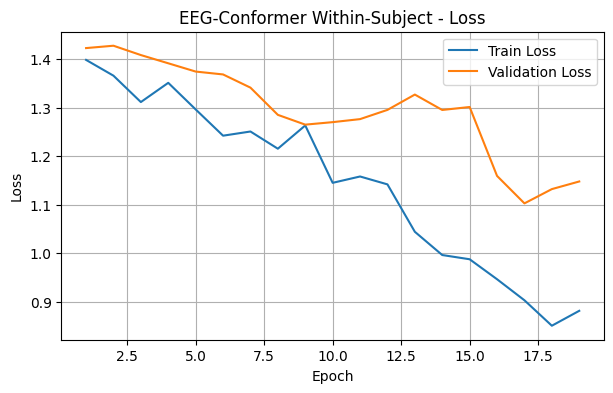

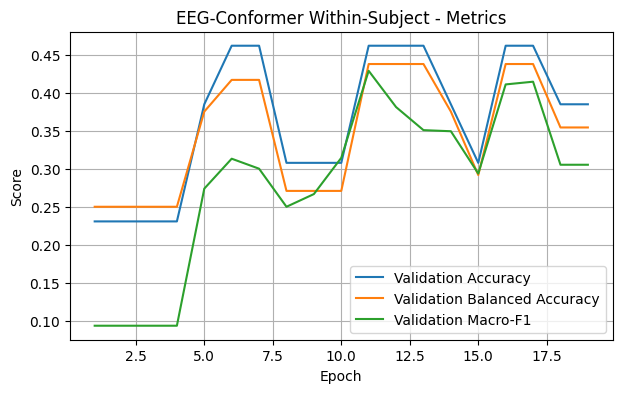

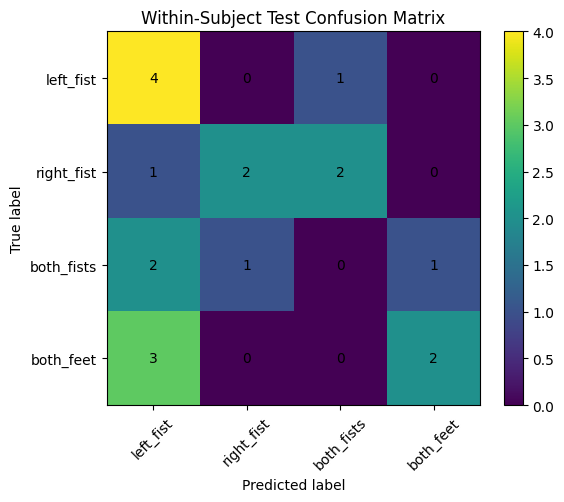


Classification report:
              precision    recall  f1-score   support

   left_fist       0.40      0.80      0.53         5
  right_fist       0.67      0.40      0.50         5
  both_fists       0.00      0.00      0.00         4
   both_feet       0.67      0.40      0.50         5

    accuracy                           0.42        19
   macro avg       0.43      0.40      0.38        19
weighted avg       0.46      0.42      0.40        19



In [ ]:
def run_within_subject_experiment(
    subject: int = 1,
    model_name: str = "eeg_conformer",
    cfg: CFG = cfg,
    use_augmentation: bool = True,
    verbose: bool = True
):
    data = prepare_within_subject_arrays(subject=subject, cfg=cfg)

    train_loader, val_loader, test_loader = build_dataloaders_from_arrays(
        data["X_train"],
        data["y_train"],
        data["X_val"],
        data["y_val"],
        data["X_test"],
        data["y_test"],
        cfg=cfg,
        use_augmentation=use_augmentation
    )

    n_channels = data["X_train"].shape[1]

    model = build_model(
        model_name=model_name,
        n_channels=n_channels,
        cfg=cfg
    )

    model, history = train_model(
        model,
        train_loader,
        val_loader,
        cfg=cfg,
        device=device,
        verbose=verbose
    )

    test_metrics, y_true, y_pred = evaluate_model(model, test_loader, device)

    result = {
        "subject": subject,
        "model": model_name,
        "protocol": "within_subject",
        "use_augmentation": use_augmentation,
        "test_accuracy": test_metrics["accuracy"],
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_loss": test_metrics["loss"],
        "confusion_matrix": test_metrics["confusion_matrix"]
    }

    return model, history, result, data, test_loader, y_true, y_pred


best_model, history, within_result, within_data, test_loader, y_true, y_pred = run_within_subject_experiment(
    subject=1,
    model_name="eeg_conformer",
    cfg=cfg,
    use_augmentation=True,
    verbose=True
)

print("\nWithin-subject test result:")
print(pd.DataFrame([within_result]).drop(columns=["confusion_matrix"]))

plot_training_history(history, title="EEG-Conformer Within-Subject")
plot_confusion_matrix(within_result["confusion_matrix"], title="Within-Subject Test Confusion Matrix")

print("\nClassification report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=[LABEL_NAMES[i] for i in range(cfg.n_classes)]
))

## Experiment 2: Model benchmarking

This experiment compares EEG-Conformer with CNN-based baselines.

The goal is not simply to prove that Conformer works, but to ask:

> Does self-attention actually improve EEG decoding compared with simpler CNN architectures?

This directly addresses the limitation that Transformer-based EEG models may not always be superior in small-sample EEG settings.

In [ ]:
def benchmark_models_within_subject(
    subject: int = 1,
    model_names: List[str] = ["eeg_conformer", "eegnet_lite", "shallowconvnet_lite"],
    cfg: CFG = cfg
):
    benchmark_results = []

    for model_name in model_names:
        print("\n" + "=" * 80)
        print(f"Running model: {model_name}")
        print("=" * 80)

        model, history, result, data, loader, y_true, y_pred = run_within_subject_experiment(
            subject=subject,
            model_name=model_name,
            cfg=cfg,
            use_augmentation=True,
            verbose=False
        )

        print(
            f"{model_name} | "
            f"Acc: {result['test_accuracy']:.4f} | "
            f"Balanced Acc: {result['test_balanced_accuracy']:.4f} | "
            f"Macro-F1: {result['test_macro_f1']:.4f}"
        )

        benchmark_results.append(result)

    df = pd.DataFrame(benchmark_results)
    csv_path = os.path.join(cfg.results_dir, f"within_subject_benchmark_subject_{subject}.csv")
    df.drop(columns=["confusion_matrix"]).to_csv(csv_path, index=False)

    print("\nSaved benchmark results to:", csv_path)

    return df


benchmark_df = benchmark_models_within_subject(subject=1, cfg=cfg)
benchmark_df.drop(columns=["confusion_matrix"])


Running model: eeg_conformer
eeg_conformer | Acc: 0.4737 | Balanced Acc: 0.4500 | Macro-F1: 0.3777

Running model: eegnet_lite
eegnet_lite | Acc: 0.2632 | Balanced Acc: 0.2500 | Macro-F1: 0.1042

Running model: shallowconvnet_lite
shallowconvnet_lite | Acc: 0.4211 | Balanced Acc: 0.4000 | Macro-F1: 0.2716

Saved benchmark results to: /content/eeg_bci_results/within_subject_benchmark_subject_1.csv


,subject,model,protocol,use_augmentation,test_accuracy,test_balanced_accuracy,test_macro_f1,test_loss
0,1,eeg_conformer,within_subject,True,0.473684,0.45,0.377652,1.282210
1,1,eegnet_lite,within_subject,True,0.263158,0.25,0.104167,1.385138
2,1,shallowconvnet_lite,within_subject,True,0.421053,0.40,0.271635,1.381928


## Experiment 3: Leave-One-Subject-Out cross-subject evaluation

Within-subject performance is not enough for BCI research because the model may learn subject-specific EEG patterns.

This experiment uses Leave-One-Subject-Out evaluation:

- Train on multiple subjects.
- Test on one unseen subject.
- Repeat this process for each subject.

This directly evaluates cross-subject generalization, which is a key challenge in EEG-based BCI.

In [ ]:
def load_multiple_subjects(
    subjects: Tuple[int, ...],
    cfg: CFG = cfg
):
    subject_bank = {}

    for subject in subjects:
        print(f"Loading subject {subject}...")
        X, y, ch_names = load_eegmmidb_subject(subject=subject, cfg=cfg)

        subject_bank[subject] = {
            "X": X,
            "y": y,
            "ch_names": ch_names
        }

        print(
            f"Subject {subject}: X={X.shape}, "
            f"class distribution={ {LABEL_NAMES[i]: int(np.sum(y == i)) for i in range(cfg.n_classes)} }"
        )

    return subject_bank


# For quick Colab testing, start with 3 subjects.
# Later, change this to cfg.subjects for all selected subjects.
LOSO_SUBJECTS = cfg.subjects

subject_bank = load_multiple_subjects(LOSO_SUBJECTS, cfg=cfg)

Loading subject 1...
Subject 1: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 21, 'both_feet': 24}
Loading subject 2...


Subject 2: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 24, 'both_feet': 21}
Loading subject 3...


Subject 3: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 21, 'both_feet': 24}
Loading subject 4...


Subject 4: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 22, 'both_feet': 23}
Loading subject 5...


Subject 5: X=(90, 64, 1001), class distribution={'left_fist': 21, 'right_fist': 24, 'both_fists': 23, 'both_feet': 22}
Loading subject 6...


...

Subject 26: X=(90, 64, 1001), class distribution={'left_fist': 24, 'right_fist': 21, 'both_fists': 21, 'both_feet': 24}
Loading subject 27...


Subject 27: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 22, 'both_feet': 23}
Loading subject 28...


Subject 28: X=(90, 64, 1001), class distribution={'left_fist': 22, 'right_fist': 23, 'both_fists': 23, 'both_feet': 22}
Loading subject 29...


Subject 29: X=(90, 64, 1001), class distribution={'left_fist': 23, 'right_fist': 22, 'both_fists': 22, 'both_feet': 23}
Loading subject 30...


Subject 30: X=(90, 64, 1001), class distribution={'left_fist': 24, 'right_fist': 21, 'both_fists': 24, 'both_feet': 21}


In [ ]:
# Cell 25 — Run LOSO experiment with progress and auto-save

def run_loso_experiment(
    subject_bank: Dict,
    model_name: str = "eeg_conformer",
    cfg: CFG = cfg,
    max_folds: int = 3
):
    """
    Run Leave-One-Subject-Out cross-subject evaluation.

    If subject_bank contains 30 subjects:
    - max_folds=3 means only run the first 3 LOSO folds.
    - max_folds=10 means only run the first 10 LOSO folds.
    - max_folds=None means run all 30 LOSO folds.
    """

    loso_results = []

    all_test_subjects = sorted(list(subject_bank.keys()))

    if max_folds is not None:
        all_test_subjects = all_test_subjects[:max_folds]

    total_folds = len(all_test_subjects)

    print("Total subjects in subject_bank:", len(subject_bank))
    print("Total folds to run:", total_folds)
    print("Test subjects:", all_test_subjects)

    if len(subject_bank) == 0:
        raise RuntimeError("subject_bank is empty. Please run Cell 24 first.")

    if total_folds == 0:
        raise RuntimeError("No LOSO folds to run. Please check max_folds.")

    for fold_idx, test_subject in enumerate(all_test_subjects, start=1):

        print("\n" + "=" * 80)
        print(f"LOSO fold {fold_idx}/{total_folds}")
        print(f"Test subject = {test_subject}")
        print("=" * 80)

        start_time = time.time()

        # 1. Prepare this LOSO fold
        fold_data = prepare_loso_fold(
            subject_bank=subject_bank,
            test_subject=test_subject,
            cfg=cfg
        )

        print("Fold data shapes:")
        print("X_train:", fold_data["X_train"].shape)
        print("X_val:  ", fold_data["X_val"].shape)
        print("X_test: ", fold_data["X_test"].shape)

        # 2. Build dataloaders
        train_loader, val_loader, test_loader = build_dataloaders_from_arrays(
            fold_data["X_train"],
            fold_data["y_train"],
            fold_data["X_val"],
            fold_data["y_val"],
            fold_data["X_test"],
            fold_data["y_test"],
            cfg=cfg,
            use_augmentation=True
        )

        # 3. Build model
        n_channels = fold_data["X_train"].shape[1]

        model = build_model(
            model_name=model_name,
            n_channels=n_channels,
            cfg=cfg
        )

        # 4. Train model
        print("Start training this fold...")

        model, history = train_model(
            model,
            train_loader,
            val_loader,
            cfg=cfg,
            device=device,
            verbose=True
        )

        # 5. Test model
        print("Training finished. Start testing...")

        test_metrics, y_true, y_pred = evaluate_model(
            model,
            test_loader,
            device
        )

        used_time = time.time() - start_time

        fold_result = {
            "fold": fold_idx,
            "test_subject": test_subject,
            "model": model_name,
            "protocol": "LOSO",
            "test_accuracy": test_metrics["accuracy"],
            "test_balanced_accuracy": test_metrics["balanced_accuracy"],
            "test_macro_f1": test_metrics["macro_f1"],
            "test_loss": test_metrics["loss"],
            "used_time_seconds": used_time,
            "confusion_matrix": test_metrics["confusion_matrix"]
        }

        loso_results.append(fold_result)

        print(
            f"Finished fold {fold_idx}/{total_folds} | "
            f"Subject {test_subject} | "
            f"Acc: {fold_result['test_accuracy']:.4f} | "
            f"Balanced Acc: {fold_result['test_balanced_accuracy']:.4f} | "
            f"Macro-F1: {fold_result['test_macro_f1']:.4f} | "
            f"Time: {used_time / 60:.2f} min"
        )

        # 6. Auto-save partial results after each fold
        partial_df = pd.DataFrame(loso_results)

        partial_csv_path = os.path.join(
            cfg.results_dir,
            f"loso_{model_name}_partial_results.csv"
        )

        partial_df.drop(
            columns=["confusion_matrix"],
            errors="ignore"
        ).to_csv(
            partial_csv_path,
            index=False
        )

        print("Partial results saved to:", partial_csv_path)

    # 7. Save final results
    loso_df = pd.DataFrame(loso_results)

    final_csv_path = os.path.join(
        cfg.results_dir,
        f"loso_{model_name}_final_results.csv"
    )

    loso_df.drop(
        columns=["confusion_matrix"],
        errors="ignore"
    ).to_csv(
        final_csv_path,
        index=False
    )

    print("\nFinal LOSO results saved to:", final_csv_path)

    return loso_df


# ================================
# Run LOSO
# ================================

# 先跑 3 折，比较适合控制在 1 小时内
# 如果之后想跑 10 折，把 RUN_FOLDS 改成 10
# 如果之后想跑完整 30 折，把 RUN_FOLDS 改成 None

RUN_FOLDS = 3

loso_df = run_loso_experiment(
    subject_bank=subject_bank,
    model_name="eeg_conformer",
    cfg=cfg,
    max_folds=RUN_FOLDS
)

loso_df.drop(
    columns=["confusion_matrix"],
    errors="ignore"
)

Total subjects in subject_bank: 30
Total folds to run: 3
Test subjects: [1, 2, 3]

LOSO fold 1/3
Test subject = 1
Fold data shapes:
X_train: (2218, 64, 1001)
X_val:   (392, 64, 1001)
X_test:  (90, 64, 1001)
Start training this fold...
Epoch 001 | Train Loss: 1.3963 | Val Loss: 1.4203 | Val Acc: 0.2500 | Val Macro-F1: 0.2364
Epoch 002 | Train Loss: 1.3632 | Val Loss: 1.4662 | Val Acc: 0.2730 | Val Macro-F1: 0.1933
Epoch 003 | Train Loss: 1.3286 | Val Loss: 1.6756 | Val Acc: 0.2602 | Val Macro-F1: 0.1864
Epoch 004 | Train Loss: 1.3027 | Val Loss: 1.4927 | Val Acc: 0.3138 | Val Macro-F1: 0.2562
Epoch 005 | Train Loss: 1.2745 | Val Loss: 1.8258 | Val Acc: 0.2781 | Val Macro-F1: 0.2051
Epoch 006 | Train Loss: 1.2392 | Val Loss: 1.6102 | Val Acc: 0.3265 | Val Macro-F1: 0.2918
Epoch 007 | Train Loss: 1.2084 | Val Loss: 1.5461 | Val Acc: 0.3469 | Val Macro-F1: 0.3428
Epoch 008 | Train Loss: 1.1841 | Val Loss: 1.5227 | Val Acc: 0.3291 | Val Macro-F1: 0.3243
Epoch 009 | Train Loss: 1.1616 | Val 

,fold,test_subject,model,protocol,test_accuracy,test_balanced_accuracy,test_macro_f1,test_loss,used_time_seconds
0,1,1,eeg_conformer,LOSO,0.333333,0.334010,0.268232,2.027713,255.912001
1,2,2,eeg_conformer,LOSO,0.455556,0.442758,0.405147,1.548791,265.866992
2,3,3,eeg_conformer,LOSO,0.266667,0.277150,0.214347,1.595755,207.531828


## Experiment 4: Attention visualization

This experiment inspects the attention maps of EEG-Conformer.

The goal is not to claim that attention is a causal explanation, but to analyze whether the model attends to specific temporal-token relationships.

This makes the project more interpretable and more relevant to computational neuroscience.

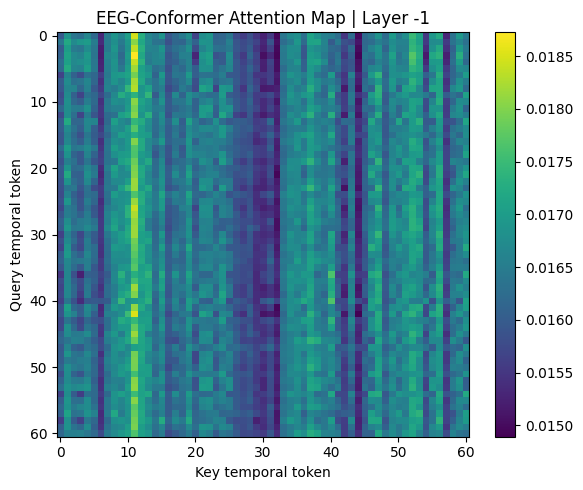

In [ ]:
def get_one_batch(loader):
    for x, y in loader:
        return x, y


def plot_conformer_attention(model, loader, device=device, layer_index: int = -1):
    if not isinstance(model, EEGConformer):
        print("Attention visualization is only available for EEGConformer.")
        return

    model.eval()

    x, y = get_one_batch(loader)
    x = x.to(device)

    with torch.no_grad():
        _ = model(x)

    attn_maps = model.get_attention_maps()

    if len(attn_maps) == 0:
        print("No attention maps found.")
        return

    attn = attn_maps[layer_index]

    # Shape: [batch, heads, tokens, tokens]
    attn_mean = attn.mean(dim=1)[0]

    plt.figure(figsize=(6, 5))
    plt.imshow(attn_mean.numpy(), aspect="auto")
    plt.colorbar()
    plt.xlabel("Key temporal token")
    plt.ylabel("Query temporal token")
    plt.title(f"EEG-Conformer Attention Map | Layer {layer_index}")
    plt.tight_layout()
    plt.show()


plot_conformer_attention(best_model, test_loader, device=device, layer_index=-1)

## Experiment 5: Temporal occlusion analysis

Attention maps are useful but not sufficient.

Therefore, this notebook also implements temporal occlusion analysis:

1. Divide the EEG trial into temporal segments.
2. Mask one segment at a time.
3. Measure how much the model confidence drops.

If masking a specific time window causes a large confidence drop, that window may be important for the model prediction.

This provides a stronger model-level interpretation than attention visualization alone.

Predicted class: left_fist
Base confidence: 0.35966575145721436


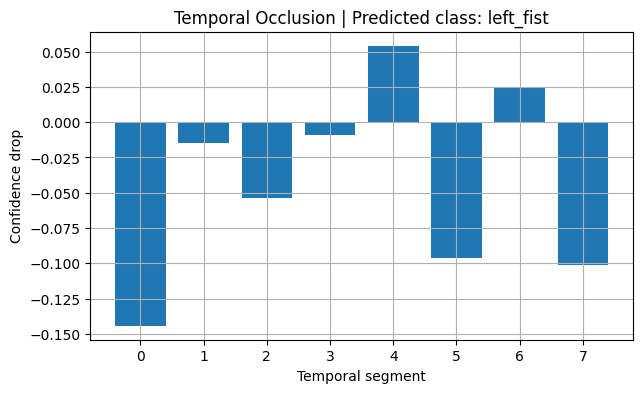

In [ ]:
@torch.no_grad()
def temporal_occlusion_analysis(
    model,
    x_trial: torch.Tensor,
    n_segments: int = 8,
    device=device
):
    """
    Temporal occlusion for one EEG trial.

    x_trial shape:
    [1, 1, n_channels, n_times]
    """

    model.eval()

    x_trial = x_trial.to(device)

    base_logits = extract_logits(model(x_trial))
    base_prob = torch.softmax(base_logits, dim=1)

    base_class = torch.argmax(base_prob, dim=1).item()
    base_conf = base_prob[0, base_class].item()

    n_times = x_trial.shape[-1]
    edges = np.linspace(0, n_times, n_segments + 1, dtype=int)

    confidence_drops = []

    for i in range(n_segments):
        start = edges[i]
        end = edges[i + 1]

        x_masked = x_trial.clone()
        x_masked[:, :, :, start:end] = 0.0

        masked_logits = extract_logits(model(x_masked))
        masked_prob = torch.softmax(masked_logits, dim=1)

        masked_conf = masked_prob[0, base_class].item()
        drop = base_conf - masked_conf

        confidence_drops.append(drop)

    return {
        "base_class": base_class,
        "base_confidence": base_conf,
        "confidence_drops": confidence_drops
    }


def plot_temporal_occlusion(occlusion_result):
    drops = occlusion_result["confidence_drops"]

    plt.figure(figsize=(7, 4))
    plt.bar(np.arange(len(drops)), drops)
    plt.xlabel("Temporal segment")
    plt.ylabel("Confidence drop")
    plt.title(
        f"Temporal Occlusion | Predicted class: {LABEL_NAMES[occlusion_result['base_class']]}"
    )
    plt.grid(True)
    plt.show()


x_batch, y_batch = get_one_batch(test_loader)
x_trial = x_batch[0:1]

occlusion_result = temporal_occlusion_analysis(
    best_model,
    x_trial,
    n_segments=8,
    device=device
)

print("Predicted class:", LABEL_NAMES[occlusion_result["base_class"]])
print("Base confidence:", occlusion_result["base_confidence"])

plot_temporal_occlusion(occlusion_result)

## Experiment 6: Pseudo-online BCI command simulation

This module simulates a pseudo-online BCI decoding scenario.

Instead of claiming real-time EEG acquisition, this notebook replays offline EEG trials and converts model predictions into BCI commands.

This provides a lightweight platform-style demo:

- EEG trial input
- Model prediction
- BCI command output

This can be extended to real online BCI by connecting live EEG streams in the future.

In [ ]:
@torch.no_grad()
def predict_bci_command(
    model,
    x_trial: torch.Tensor,
    device=device
):
    model.eval()

    x_trial = x_trial.to(device)

    logits = extract_logits(model(x_trial))
    prob = torch.softmax(logits, dim=1)

    pred_class = torch.argmax(prob, dim=1).item()
    confidence = prob[0, pred_class].item()

    command_map = {
        0: "BCI_COMMAND_LEFT",
        1: "BCI_COMMAND_RIGHT",
        2: "BCI_COMMAND_BOTH_HANDS",
        3: "BCI_COMMAND_FEET"
    }

    return {
        "predicted_class": pred_class,
        "predicted_label": LABEL_NAMES[pred_class],
        "bci_command": command_map[pred_class],
        "confidence": confidence
    }


def pseudo_online_trial_replay(
    model,
    loader,
    n_trials: int = 5,
    delay: float = 0.5,
    device=device
):
    model.eval()

    shown = 0

    for x, y in loader:
        for i in range(x.shape[0]):
            x_trial = x[i:i+1]
            y_true = y[i].item()

            result = predict_bci_command(
                model,
                x_trial,
                device=device
            )

            print("-" * 60)
            print(f"True label:      {LABEL_NAMES[y_true]}")
            print(f"Predicted label: {result['predicted_label']}")
            print(f"BCI command:     {result['bci_command']}")
            print(f"Confidence:      {result['confidence']:.4f}")

            shown += 1
            time.sleep(delay)

            if shown >= n_trials:
                return


pseudo_online_trial_replay(
    best_model,
    test_loader,
    n_trials=5,
    delay=0.2,
    device=device
)

------------------------------------------------------------
True label:      both_fists
Predicted label: left_fist
BCI command:     BCI_COMMAND_LEFT
Confidence:      0.3597
------------------------------------------------------------
True label:      right_fist
Predicted label: left_fist
BCI command:     BCI_COMMAND_LEFT
Confidence:      0.3565
------------------------------------------------------------
True label:      left_fist
Predicted label: left_fist
BCI command:     BCI_COMMAND_LEFT
Confidence:      0.4096
------------------------------------------------------------
True label:      left_fist
Predicted label: left_fist
BCI command:     BCI_COMMAND_LEFT
Confidence:      0.3617
------------------------------------------------------------
True label:      right_fist
Predicted label: right_fist
BCI command:     BCI_COMMAND_RIGHT
Confidence:      0.4579


## Experiment 7: Transformer-depth ablation

This experiment tests whether deeper Transformer encoders actually improve EEG decoding.

The key question is:

> Is self-attention useful in this small-sample EEG setting, or does it mainly increase model capacity and overfitting risk?

This ablation provides a concrete research insight rather than only reporting one model result.

In [ ]:
def run_depth_ablation(
    subject: int = 1,
    depths: List[int] = [0, 2, 4, 6],
    cfg: CFG = cfg
):
    ablation_results = []

    data = prepare_within_subject_arrays(subject=subject, cfg=cfg)

    train_loader, val_loader, test_loader = build_dataloaders_from_arrays(
        data["X_train"],
        data["y_train"],
        data["X_val"],
        data["y_val"],
        data["X_test"],
        data["y_test"],
        cfg=cfg,
        use_augmentation=True
    )

    n_channels = data["X_train"].shape[1]

    for depth in depths:
        print("\n" + "=" * 80)
        print(f"Running EEG-Conformer with Transformer depth = {depth}")
        print("=" * 80)

        model = EEGConformer(
            n_channels=n_channels,
            n_classes=cfg.n_classes,
            emb_size=cfg.emb_size,
            depth=depth,
            n_heads=cfg.n_heads,
            dropout=cfg.dropout
        )

        model, history = train_model(
            model,
            train_loader,
            val_loader,
            cfg=cfg,
            device=device,
            verbose=False
        )

        test_metrics, y_true, y_pred = evaluate_model(
            model,
            test_loader,
            device
        )

        result = {
            "subject": subject,
            "model": "eeg_conformer",
            "transformer_depth": depth,
            "test_accuracy": test_metrics["accuracy"],
            "test_balanced_accuracy": test_metrics["balanced_accuracy"],
            "test_macro_f1": test_metrics["macro_f1"],
            "test_loss": test_metrics["loss"]
        }

        ablation_results.append(result)

        print(
            f"Depth {depth} | "
            f"Acc: {result['test_accuracy']:.4f} | "
            f"Balanced Acc: {result['test_balanced_accuracy']:.4f} | "
            f"Macro-F1: {result['test_macro_f1']:.4f}"
        )

    df = pd.DataFrame(ablation_results)

    csv_path = os.path.join(cfg.results_dir, f"depth_ablation_subject_{subject}.csv")
    df.to_csv(csv_path, index=False)

    print("\nSaved depth ablation results to:", csv_path)

    return df


depth_ablation_df = run_depth_ablation(
    subject=1,
    depths=[0, 2, 4, 6],
    cfg=cfg
)

depth_ablation_df


Running EEG-Conformer with Transformer depth = 0
Depth 0 | Acc: 0.5263 | Balanced Acc: 0.5125 | Macro-F1: 0.5095

Running EEG-Conformer with Transformer depth = 2
Depth 2 | Acc: 0.4737 | Balanced Acc: 0.4750 | Macro-F1: 0.4590

Running EEG-Conformer with Transformer depth = 4
Depth 4 | Acc: 0.2632 | Balanced Acc: 0.2500 | Macro-F1: 0.1801

Running EEG-Conformer with Transformer depth = 6
Depth 6 | Acc: 0.3684 | Balanced Acc: 0.3500 | Macro-F1: 0.2389

Saved depth ablation results to: /content/eeg_bci_results/depth_ablation_subject_1.csv


,subject,model,transformer_depth,test_accuracy,test_balanced_accuracy,test_macro_f1,test_loss
0,1,eeg_conformer,0,0.526316,0.5125,0.509524,1.188321
1,1,eeg_conformer,2,0.473684,0.4750,0.459041,1.144647
2,1,eeg_conformer,4,0.263158,0.2500,0.180147,1.354024
3,1,eeg_conformer,6,0.368421,0.3500,0.238889,1.473213


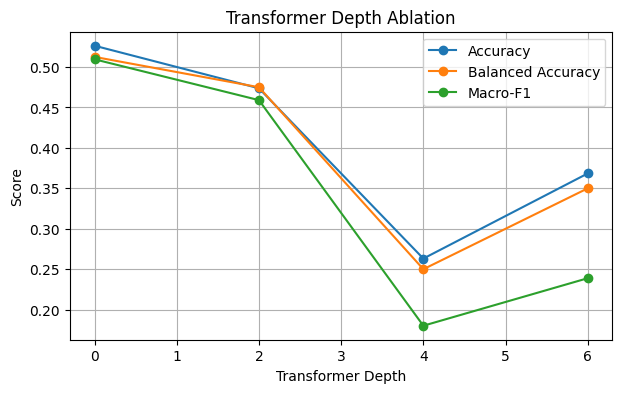

In [ ]:
def plot_depth_ablation(df):
    plt.figure(figsize=(7, 4))
    plt.plot(df["transformer_depth"], df["test_accuracy"], marker="o", label="Accuracy")
    plt.plot(df["transformer_depth"], df["test_balanced_accuracy"], marker="o", label="Balanced Accuracy")
    plt.plot(df["transformer_depth"], df["test_macro_f1"], marker="o", label="Macro-F1")

    plt.xlabel("Transformer Depth")
    plt.ylabel("Score")
    plt.title("Transformer Depth Ablation")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_depth_ablation(depth_ablation_df)

## Save project artifacts

This cell saves:

1. Best EEG-Conformer model checkpoint.
2. Within-subject metrics.
3. Benchmark results.
4. LOSO results.
5. Ablation results.

These saved outputs can be used to update the GitHub repository and CV project description.

In [ ]:
checkpoint_path = os.path.join(cfg.results_dir, "best_eeg_conformer_subject_1.pt")

torch.save(
    {
        "model_state_dict": best_model.state_dict(),
        "cfg": cfg.__dict__,
        "within_result": within_result
    },
    checkpoint_path
)

print("Saved model checkpoint to:", checkpoint_path)

within_result_path = os.path.join(cfg.results_dir, "within_subject_result_subject_1.csv")
pd.DataFrame([within_result]).drop(columns=["confusion_matrix"]).to_csv(
    within_result_path,
    index=False
)

print("Saved within-subject result to:", within_result_path)

print("\nAll results are saved in:")
print(cfg.results_dir)

Saved model checkpoint to: /content/eeg_bci_results/best_eeg_conformer_subject_1.pt
Saved within-subject result to: /content/eeg_bci_results/within_subject_result_subject_1.csv

All results are saved in:
/content/eeg_bci_results
